In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import datasets

print("PyArrow:", pyarrow.__version__)
print("Datasets:", datasets.__version__)

PyArrow: 25.0.1
Datasets: 5.0.1


In [2]:
!pip install -U datasets huggingface_hub -q

In [3]:
!pip uninstall -y pyarrow datasets
!pip install -q datasets pyarrow

from datasets import load_dataset
dataset = load_dataset("fancyzhx/dbpedia_14")

Found existing installation: pyarrow 25.0.1
Uninstalling pyarrow-25.0.1:
  Successfully uninstalled pyarrow-25.0.1
Found existing installation: datasets 5.0.1
Uninstalling datasets-5.0.1:
  Successfully uninstalled datasets-5.0.1


README.md:   0%|          | 0.00/7.64k [00:00<?, ?B/s]

dbpedia_14/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  106MB            

dbpedia_14/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

dbpedia_14/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 13.3MB            

dbpedia_14/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/70000 [00:00<?, ? examples/s]

In [4]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 70000
    })
})


In [5]:
label_names = dataset["train"].features["label"].names
print(label_names)

['Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder', 'MeanOfTransportation', 'Building', 'NaturalPlace', 'Village', 'Animal', 'Plant', 'Album', 'Film', 'WrittenWork']


In [6]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

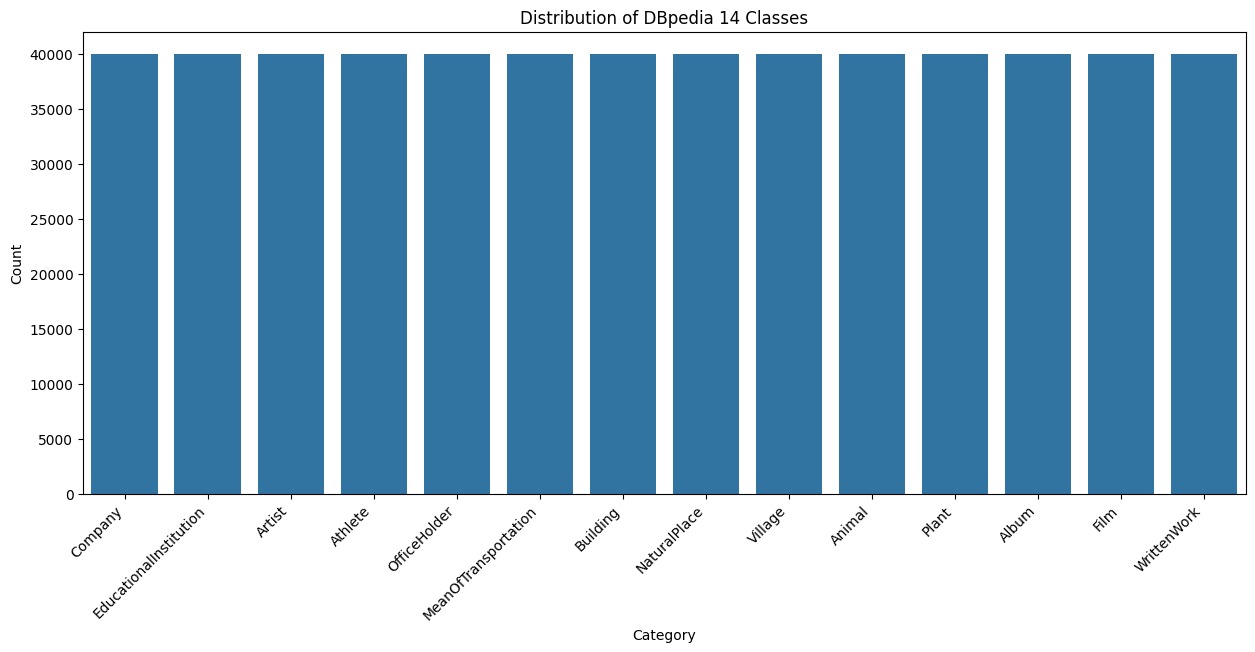

In [7]:
plt.figure(figsize=(15, 6))
sns.countplot(
    x="label",
    data=train_df,
    order=range(len(label_names))
)
plt.xticks(
    ticks=range(len(label_names)),
    labels=label_names,
    rotation=45,
    ha="right"
)
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Distribution of DBpedia 14 Classes")
plt.show()

In [8]:
train_df.isna().sum()

,0
label,0
title,0
content,0


In [9]:
train_df.head(5)

,label,title,content
0,0,E. D. Abbott Ltd,Abbott of Farnham E D Abbott Limited was a Br...
1,0,Schwan-Stabilo,Schwan-STABILO is a German maker of pens for ...
2,0,Q-workshop,Q-workshop is a Polish company located in Poz...
3,0,Marvell Software Solutions Israel,Marvell Software Solutions Israel known as RA...
4,0,Bergan Mercy Medical Center,Bergan Mercy Medical Center is a hospital loc...


In [10]:
def preprocess(text):
    text = text.lower()
    text = text.replace('\n', ' ')
    text = " ".join(text.split())

    return text

In [19]:
train_df = train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [20]:
test_df = test_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [21]:
print(train_df["label"].head(20))

0      0
1      5
2      2
3      9
4      7
5     11
6      2
7      3
8      3
9      6
10     7
11     7
12    12
13    12
14    12
15     4
16     0
17     5
18    10
19     1
Name: label, dtype: int64


In [22]:
X_train = (
    train_df["title"].fillna("") + " " +
    train_df["content"].fillna("")
)
Y_train = train_df["label"]
X_test = (
    test_df["title"].fillna("") + " " +
    test_df["content"].fillna("")
)
Y_test = test_df["label"]

In [23]:
X_train = X_train.apply(preprocess)
X_test = X_test.apply(preprocess)

In [24]:
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 30000
max_length = 100

tokenize = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenize.fit_on_texts(X_train)

train_sequence = tokenize.texts_to_sequences(X_train)
test_sequence = tokenize.texts_to_sequences(X_test)

padded_train_sequence = pad_sequences(
    train_sequence,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

padded_test_sequence = pad_sequences(
    test_sequence,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

train_labels = np.array(Y_train)
test_labels = np.array(Y_test)

num_classes = len(np.unique(train_labels))
total_vocab_size = len(tokenize.word_index) + 1
vocab_size = min(max_words, total_vocab_size)

print(f"Number of classes: {num_classes}")
print(f"Total words found: {total_vocab_size}")
print(f"Max words allowed: {max_words}")
print(f"Vocabulary size used: {vocab_size}")
print(f"Max sentence length: {padded_train_sequence.shape[1]}")

Number of classes: 14
Total words found: 730802
Max words allowed: 30000
Vocabulary size used: 30000
Max sentence length: 100


In [25]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential([

    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    SimpleRNN(
        units=128,
        dropout=0.2
    ),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(
        num_classes,
        activation='softmax'
    )
])

In [29]:
optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

rnn_model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history = rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    shuffle=True
)
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    padded_test_sequence,
    test_labels
)
print(f"RNN Loss: {rnn_loss:.4f}")
print(f"RNN Accuracy: {rnn_accuracy:.4f}")

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.4102 - loss: 1.6061 - val_accuracy: 0.5742 - val_loss: 1.1790
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.6305 - loss: 1.0495 - val_accuracy: 0.7683 - val_loss: 0.7043
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8557 - loss: 0.5073 - val_accuracy: 0.8868 - val_loss: 0.3877
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8899 - loss: 0.4303 - val_accuracy: 0.9167 - val_loss: 0.3570
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8734 - loss: 0.4946 - val_accuracy: 0.8360 - val_loss: 0.6118
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8861 - loss: 0.4408 - val_accuracy: 0.9350 - val_loss: 0.2703
Epoch 7/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9280 - loss: 0.3119 - val_accuracy: 0.9251 - val_loss: 0.2998
Epoch 8/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9260 -

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

lstm_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128
    ),
    LSTM(
        units=128,
        dropout=0.2
    ),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(
        units=num_classes,
        activation='softmax'
    )
])

optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

lstm_model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()
history_lstm = lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    shuffle=True
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(
    padded_test_sequence,
    test_labels
)

print(f"\nLSTM Loss: {lstm_loss:.4f}")
print(f"LSTM Accuracy: {lstm_accuracy:.4f}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.1082 - loss: 2.5057 - val_accuracy: 0.1164 - val_loss: 2.4751
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.7167 - loss: 0.7285 - val_accuracy: 0.9732 - val_loss: 0.1041
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9785 - loss: 0.0941 - val_accuracy: 0.9830 - val_loss: 0.0693
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 44s 20ms/step - accuracy: 0.9875 - loss: 0.0543 - val_accuracy: 0.9858 - val_loss: 0.0592
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9910 - loss: 0.0386 - val_accuracy: 0.9862 - val_loss: 0.0584
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9934 - loss: 0.0288 - val_accuracy: 0.9858 - val_loss: 0.0609
Epoch 7/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9949 - loss: 0.0221 - val_accuracy: 0.9860 - val_loss: 0.0652
Epoch 8/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 36s 20ms/step - accuracy: 0.9961 -

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

gru_model = Sequential([

    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    GRU(
        units=128,
        dropout=0.2
    ),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(
        units=num_classes,
        activation='softmax'
    )
])

optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

gru_model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

history_gru = gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    shuffle=True
)

gru_loss, gru_accuracy = gru_model.evaluate(
    padded_test_sequence,
    test_labels
)

print(f"\nGRU Loss: {gru_loss:.4f}")
print(f"GRU Accuracy: {gru_accuracy:.4f}")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.0716 - loss: 2.6391 - val_accuracy: 0.0708 - val_loss: 2.6388
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.7661 - loss: 0.6864 - val_accuracy: 0.9842 - val_loss: 0.0651
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - accuracy: 0.9850 - loss: 0.0638 - val_accuracy: 0.9871 - val_loss: 0.0544
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9906 - loss: 0.0402 - val_accuracy: 0.9873 - val_loss: 0.0566
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9932 - loss: 0.0281 - val_accuracy: 0.9861 - val_loss: 0.0623
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9949 - loss: 0.0204 - val_accuracy: 0.9862 - val_loss: 0.0682
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9872 - loss: 0.0534

GRU Loss: 0.0534
GRU Accuracy: 0.9872


In [33]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(
    by='Test Accuracy',
    ascending=False
).reset_index(drop=True)

result_df

,Model,Test Loss,Test Accuracy
0,GRU,0.053351,0.987157
1,LSTM,0.058277,0.986400
2,RNN,0.274616,0.933900


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

BiGRU = Sequential([

    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    Bidirectional(
        GRU(128, dropout=0.2)
    ),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(
        num_classes,
        activation='softmax'
    )
])

optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

BiGRU.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
BiGRU.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_bigru = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [43]:
history_bigru = BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping_bigru],
    shuffle=True
)

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.9281 - loss: 0.2353 - val_accuracy: 0.9832 - val_loss: 0.0625
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.9870 - loss: 0.0522 - val_accuracy: 0.9847 - val_loss: 0.0584
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - accuracy: 0.9912 - loss: 0.0341 - val_accuracy: 0.9855 - val_loss: 0.0563
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9932 - loss: 0.0255 - val_accuracy: 0.9860 - val_loss: 0.0583
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.9950 - loss: 0.0184 - val_accuracy: 0.9844 - val_loss: 0.0705
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - accuracy: 0.9962 - loss: 0.0140 - val_accuracy: 0.9853 - val_loss: 0.0749


In [46]:
bigru_loss, bigru_accuracy = BiGRU.evaluate(
    padded_test_sequence,
    test_labels
)

print(f"BiGRU Loss: {bigru_loss:.4f}")
print(f"BiGRU Accuracy: {bigru_accuracy:.4f}")

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9864 - loss: 0.0552
BiGRU Loss: 0.0552
BiGRU Accuracy: 0.9864


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step


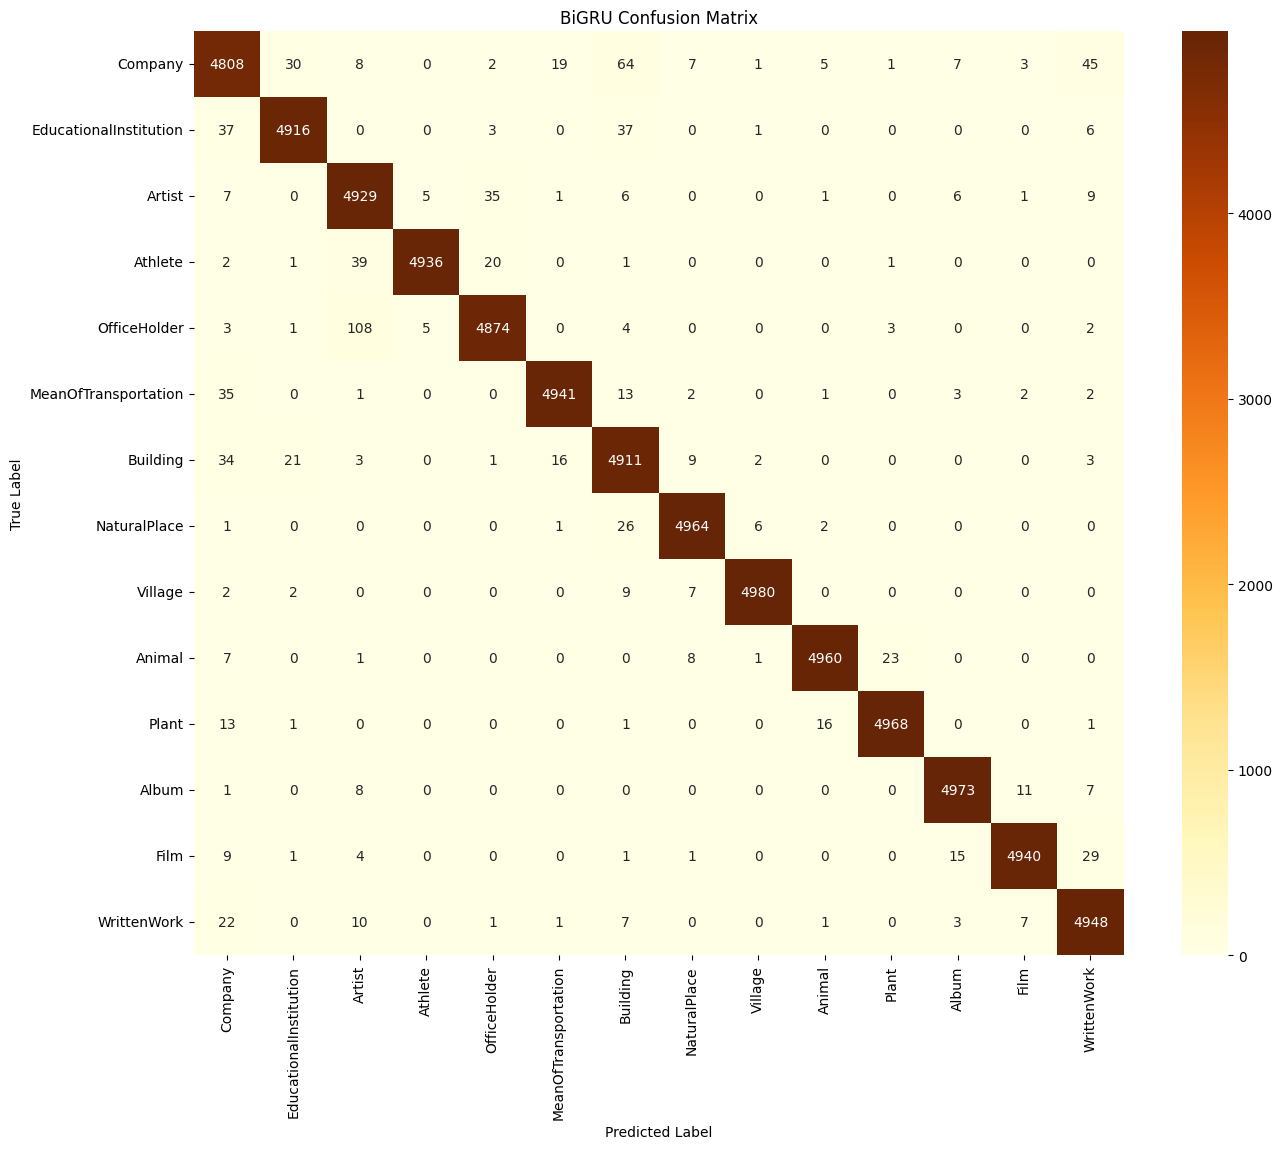

In [50]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

BiGRU_predictions = np.argmax(
    BiGRU.predict(padded_test_sequence),
    axis=1
)

cm = confusion_matrix(test_labels, BiGRU_predictions)

plt.figure(figsize=(15, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlOrBr',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BiGRU Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [51]:
sample_texts = [
    "Apple is a multinational technology company that develops smartphones and computers.",

    "Harvard University is a prestigious educational institution located in the United States.",

    "Lionel Messi is a professional football player known for his exceptional skills.",

    "The Beatles were an influential British rock band.",

    "The film received positive reviews and became a commercial success."
]


sample_sequences = tokenize.texts_to_sequences(sample_texts)

sample_padded_sequences = pad_sequences(
    sample_sequences,
    maxlen=100,
    padding='post',
    truncating='post'
)


sample_predictions = np.argmax(
    BiGRU.predict(sample_padded_sequences),
    axis=1
)


for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}")
    print(f"Predicted Category: {label_names[sample_predictions[i]]}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Text: Apple is a multinational technology company that develops smartphones and computers.
Predicted Category: Company

Text: Harvard University is a prestigious educational institution located in the United States.
Predicted Category: EducationalInstitution

Text: Lionel Messi is a professional football player known for his exceptional skills.
Predicted Category: Athlete

Text: The Beatles were an influential British rock band.
Predicted Category: Album

Text: The film received positive reviews and became a commercial success.
Predicted Category: Film

